# CIS 5450 Final Project
## Predicting New York Airbnb Prices Using Airbnb Open Data

### Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from collections import Counter
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor

### Load the dataset

In [2]:
#Read Dataset
org_df = pd.read_csv('D:/CIS545_Proj/dataset/Airbnb_Open_Data.csv')
org_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              102599 non-null  int64  
 1   NAME                            102349 non-null  object 
 2   host id                         102599 non-null  int64  
 3   host_identity_verified          102310 non-null  object 
 4   host name                       102193 non-null  object 
 5   neighbourhood group             102570 non-null  object 
 6   neighbourhood                   102583 non-null  object 
 7   lat                             102591 non-null  float64
 8   long                            102591 non-null  float64
 9   country                         102067 non-null  object 
 10  country code                    102468 non-null  object 
 11  instant_bookable                102494 non-null  object 
 12  cancellation_pol

C:\Users\asus\anaconda3\lib\site-packages\IPython\core\interactiveshell.py:3185: DtypeWarning: Columns (25) have mixed types.Specify dtype option on import or set low_memory=False.
  has_raised = await self.run_ast_nodes(code_ast.body, cell_name,


### Data Preprocessing
1. Drop duplicates data
2. Drop Unimportant features for training
3. Convert column "price" and "service fee" to float data type
4. Correct basic logistic problems in column "availability 365" and "minimum nights"
5. Correct the typo in column "neighbourhood"
6. Drop null values

In [3]:
#Drop duplicates data
org_df.drop_duplicates(inplace=True)

#Drop unimportant feature
cl_drop = ['id','NAME','host id','host name','country','country code','last review','reviews per month', 'license', 'neighbourhood','lat','long','house_rules']
org_df.drop(columns=cl_drop, inplace=True)

#Convert Price to float type
org_df['price'] = org_df['price'].replace('[\$,]', '', regex=True).astype(float)
org_df['service fee'] = org_df['service fee'].replace('[\$,]', '', regex=True).astype(float)

#Remove availabile days less than 0 
org_df['availability 365'] = np.where(org_df['availability 365']<0, org_df['availability 365']*-1, org_df['availability 365'])
#Remove availabile days more than 365
org_df['availability 365'] = np.where(org_df['availability 365']>365, 365, org_df['availability 365'])

#Remove minimum nights less than 0 
org_df['minimum nights'] = np.where(org_df['minimum nights']<0, org_df['minimum nights']*-1, org_df['minimum nights'])

#Remove typo in neighbourhood
org_df.rename(columns = {'neighbourhood group':'neighbourhood_group'}, inplace = True)
org_df = org_df[org_df.neighbourhood_group != 'brookln']

# Drop null values
final_df = org_df.dropna()

final_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 99590 entries, 0 to 102044
Data columns (total 13 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   host_identity_verified          99590 non-null  object 
 1   neighbourhood_group             99590 non-null  object 
 2   instant_bookable                99590 non-null  object 
 3   cancellation_policy             99590 non-null  object 
 4   room type                       99590 non-null  object 
 5   Construction year               99590 non-null  float64
 6   price                           99590 non-null  float64
 7   service fee                     99590 non-null  float64
 8   minimum nights                  99590 non-null  float64
 9   number of reviews               99590 non-null  float64
 10  review rate number              99590 non-null  float64
 11  calculated host listings count  99590 non-null  float64
 12  availability 365               

In [4]:
final_df.head(5)

,host_identity_verified,neighbourhood_group,instant_bookable,cancellation_policy,room type,Construction year,price,service fee,minimum nights,number of reviews,review rate number,calculated host listings count,availability 365
0,unconfirmed,Brooklyn,False,strict,Private room,2020.0,966.0,193.0,10.0,9.0,4.0,6.0,286.0
1,verified,Manhattan,False,moderate,Entire home/apt,2007.0,142.0,28.0,30.0,45.0,4.0,2.0,228.0
3,unconfirmed,Brooklyn,True,moderate,Entire home/apt,2005.0,368.0,74.0,30.0,270.0,4.0,1.0,322.0
4,verified,Manhattan,False,moderate,Entire home/apt,2009.0,204.0,41.0,10.0,9.0,3.0,1.0,289.0
5,verified,Manhattan,True,flexible,Entire home/apt,2013.0,577.0,115.0,3.0,74.0,3.0,1.0,365.0


### Visualize the numerical data in the dataset

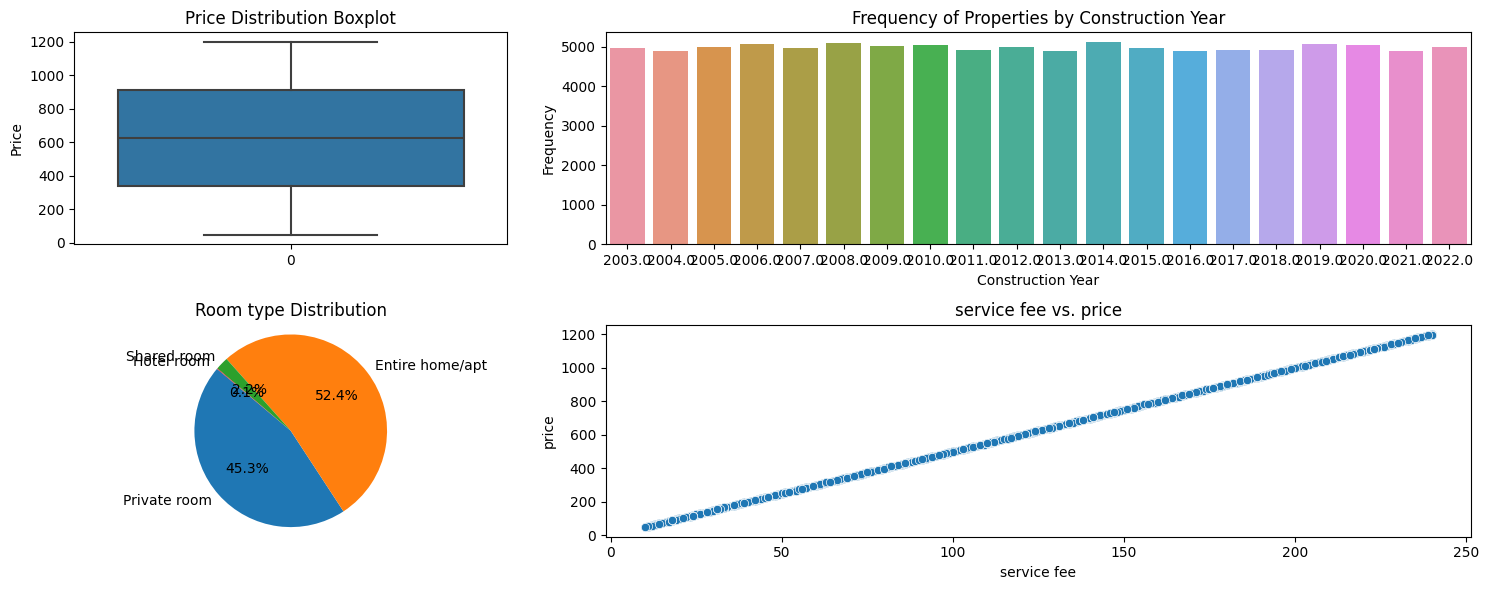

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(15, 6),gridspec_kw={'width_ratios': [1, 2]})

sns.boxplot(data=final_df['price'],ax=axes[0,0])
axes[0,0].set_title("Price Distribution Boxplot")
axes[0,0].set_ylabel("Price")

sns.countplot(x='Construction year', data=final_df,ax=axes[0,1])
axes[0,1].set_title("Frequency of Properties by Construction Year")
axes[0,1].set_xlabel("Construction Year")
axes[0,1].set_ylabel("Frequency")

label_counts = Counter(final_df['room type'])
labels_unique = list(label_counts.keys())
sizes = list(label_counts.values())
axes[1,0].pie(sizes, labels=labels_unique, autopct='%1.1f%%', startangle=140)
axes[1,0].axis('equal')
axes[1,0].set_title('Room type Distribution')

sns.scatterplot(x='service fee', y='price', data=final_df,ax=axes[1,1])

axes[1,1].set_title("service fee vs. price")
axes[1,1].set_xlabel("service fee")
axes[1,1].set_ylabel("price")

plt.tight_layout()
plt.show()

### Encode the object features with LabelEncoder / OneHotEncoder

In [6]:
#Encode possible oridinal object type features with LabelEncoder
cl_en = ['host_identity_verified','instant_bookable','cancellation_policy']
encoder = LabelEncoder()
for column in cl_en:
    final_df[column] = encoder.fit_transform(final_df[column])
    

#Encode object type features with OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)
encoded_array = encoder.fit_transform(final_df[['neighbourhood_group','room type']])
encoded_df = pd.DataFrame(
    encoded_array, 
    columns=encoder.get_feature_names_out(['neighbourhood_group', 'room type']),
    index=final_df.index
)
final_df = pd.concat([final_df, encoded_df], axis=1)
final_df.drop(columns=['neighbourhood_group','room type'], inplace=True)



C:\Users\asus\AppData\Local\Temp\ipykernel_30596\3154745680.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df[column] = encoder.fit_transform(final_df[column])
C:\Users\asus\AppData\Local\Temp\ipykernel_30596\3154745680.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df[column] = encoder.fit_transform(final_df[column])
C:\Users\asus\AppData\Local\Temp\ipykernel_30596\3154745680.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .l

In [10]:
final_df.head(5)

,host_identity_verified,instant_bookable,cancellation_policy,Construction year,price,service fee,minimum nights,number of reviews,review rate number,calculated host listings count,availability 365,neighbourhood_group_Bronx,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island,room type_Entire home/apt,room type_Hotel room,room type_Private room,room type_Shared room
0,0,0,2,2020.0,966.0,193.0,10.0,9.0,4.0,6.0,286.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,1,0,1,2007.0,142.0,28.0,30.0,45.0,4.0,2.0,228.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0,1,1,2005.0,368.0,74.0,30.0,270.0,4.0,1.0,322.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,1,0,1,2009.0,204.0,41.0,10.0,9.0,3.0,1.0,289.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
5,1,1,0,2013.0,577.0,115.0,3.0,74.0,3.0,1.0,365.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0


### Train and Test set split

In [17]:
X = final_df.drop(columns=['price'], axis=1).values
y = final_df['price'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred) *100
print(mse,r2)

2.0116499268359322 99.99816110178118


In [9]:
# model = RandomForestRegressor(n_estimators=100, random_state=42)
# model.fit(X_train,y_train)

# importance = model.feature_importances_

# feature_importance_df = pd.DataFrame({
#     'Feature': [f'Feature {i+1}' for i in range(X.shape[1])],
#     'Importance': importance
# })

# feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# plt.figure(figsize=(8, 6))
# plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
# plt.xlabel('Feature Importance')
# plt.title('Feature Importance from Random Forest Model')
# plt.show()